In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
# Make grid
b_I = 8
t1 = 10
cv_b_I, cv_t1 = 0.5, 0.5

d_IE = 3.8*10**(-4)
T_I = 2

infection_type = 'prim' #'prim' or 'sec'
sim_kind = "pop_ode"

runs = 1000
mi_args = np.arange(10,len(stat_names)) # modify: 0 = a1_0, 1 = b_a1, 2 = t1


def comp_MI(cv_b_N = 0,cv_b_E = 0, cv_b_cM = 0 , cv_b_c1 = 0):

    Is = np.random.lognormal(mean = np.log(np.array([b_I, t1])/np.sqrt(1 + np.array([cv_b_I, cv_t1])**2)), 
                            sigma = np.sqrt(np.log(1 + np.array([cv_b_I, cv_t1])**2)), size = (runs,2))
    
    # choose which parameter to vary
    run_b_Ns = np.array(Parallel(n_jobs=os.cpu_count(), batch_size = max(int(len(Is)/8),1))(delayed(sum_sim)(b_I = param[0], t1 = param[1],
                                                                                                        regulation_coeffs = [psi_N_I, psi_N_c, psi_cM_I, psi_cM_c, psi_E_I, psi_E_c],
                                                                                                        rate_cv = [cv_b_N, 0, 0, 0],
                                                                                                        infection = infection_type,
                                                                                                        sim_kind = sim_kind)
                                                    for param in Is))
    
    
    run_b_Es = np.array(Parallel(n_jobs=os.cpu_count(), batch_size = max(int(len(Is)/8),1))(delayed(sum_sim)(b_I = param[0], t1 = param[1],
                                                                                                        regulation_coeffs = [psi_N_I, psi_N_c, psi_cM_I, psi_cM_c, psi_E_I, psi_E_c],
                                                                                                        rate_cv = [0, cv_b_E, 0, 0],
                                                                                                        infection = infection_type,
                                                                                                        sim_kind = sim_kind)
                                                    for param in Is))
    
    run_b_cMs = np.array(Parallel(n_jobs=os.cpu_count(), batch_size = max(int(len(Is)/8),1))(delayed(sum_sim)(b_I = param[0], t1 = param[1],
                                                                                                        regulation_coeffs = [psi_N_I, psi_N_c, psi_cM_I, psi_cM_c, psi_E_I, psi_E_c],
                                                                                                        rate_cv = [0, 0, cv_b_cM, 0],
                                                                                                        infection = infection_type,
                                                                                                        sim_kind = sim_kind)
                                                    for param in Is))
    
    run_b_c1s = np.array(Parallel(n_jobs=os.cpu_count(), batch_size = max(int(len(Is)/8),1))(delayed(sum_sim)(b_I = param[0], t1 = param[1],
                                                                                                        regulation_coeffs = [psi_N_I, psi_N_c, psi_cM_I, psi_cM_c, psi_E_I, psi_E_c],
                                                                                                        rate_cv = [0, 0, 0, cv_b_c1],
                                                                                                        infection = infection_type,
                                                                                                        sim_kind = sim_kind)
                                                    for param in Is))
    
    # compute mutual information
    MI_b_Ns = np.zeros(2*len(mi_args))
    MI_b_Es = np.zeros(2*len(mi_args))
    MI_b_cMs = np.zeros(2*len(mi_args))
    MI_b_c1s = np.zeros(2*len(mi_args))
        
    for i, index in enumerate(mi_args):
        MI_b_Ns[i], MI_b_Ns[i+8] = calc_MI(run_b_Ns[:,7], run_b_Ns[:,index]), calc_MI(run_b_Ns[:,8], run_b_Ns[:,index])
        MI_b_Es[i], MI_b_Es[i+8] = calc_MI(run_b_Es[:,7], run_b_Es[:,index]), calc_MI(run_b_Es[:,8], run_b_Es[:,index])
        MI_b_cMs[i], MI_b_cMs[i+8] = calc_MI(run_b_cMs[:,7], run_b_cMs[:,index]), calc_MI(run_b_cMs[:,8], run_b_cMs[:,index])
        MI_b_c1s[i], MI_b_c1s[i+8] = calc_MI(run_b_c1s[:,7], run_b_c1s[:,index]), calc_MI(run_b_c1s[:,8], run_b_c1s[:,index])
        
    return  np.hstack((MI_b_Ns, MI_b_Es, MI_b_cMs, MI_b_c1s))

In [3]:
# generate 2 2d grids for the b_E & g_ME bounds
n = 10
cv_s = np.linspace(0, 2, n)

# Run simulations
mi_data = np.array(Parallel(n_jobs=os.cpu_count(), 
                              batch_size=max(int(len(cv_s)/8),1))(delayed(comp_MI)(cv_b_N = cv, cv_b_E = cv, cv_b_cM = cv, cv_b_c1 = cv)
                                              for cv in cv_s))

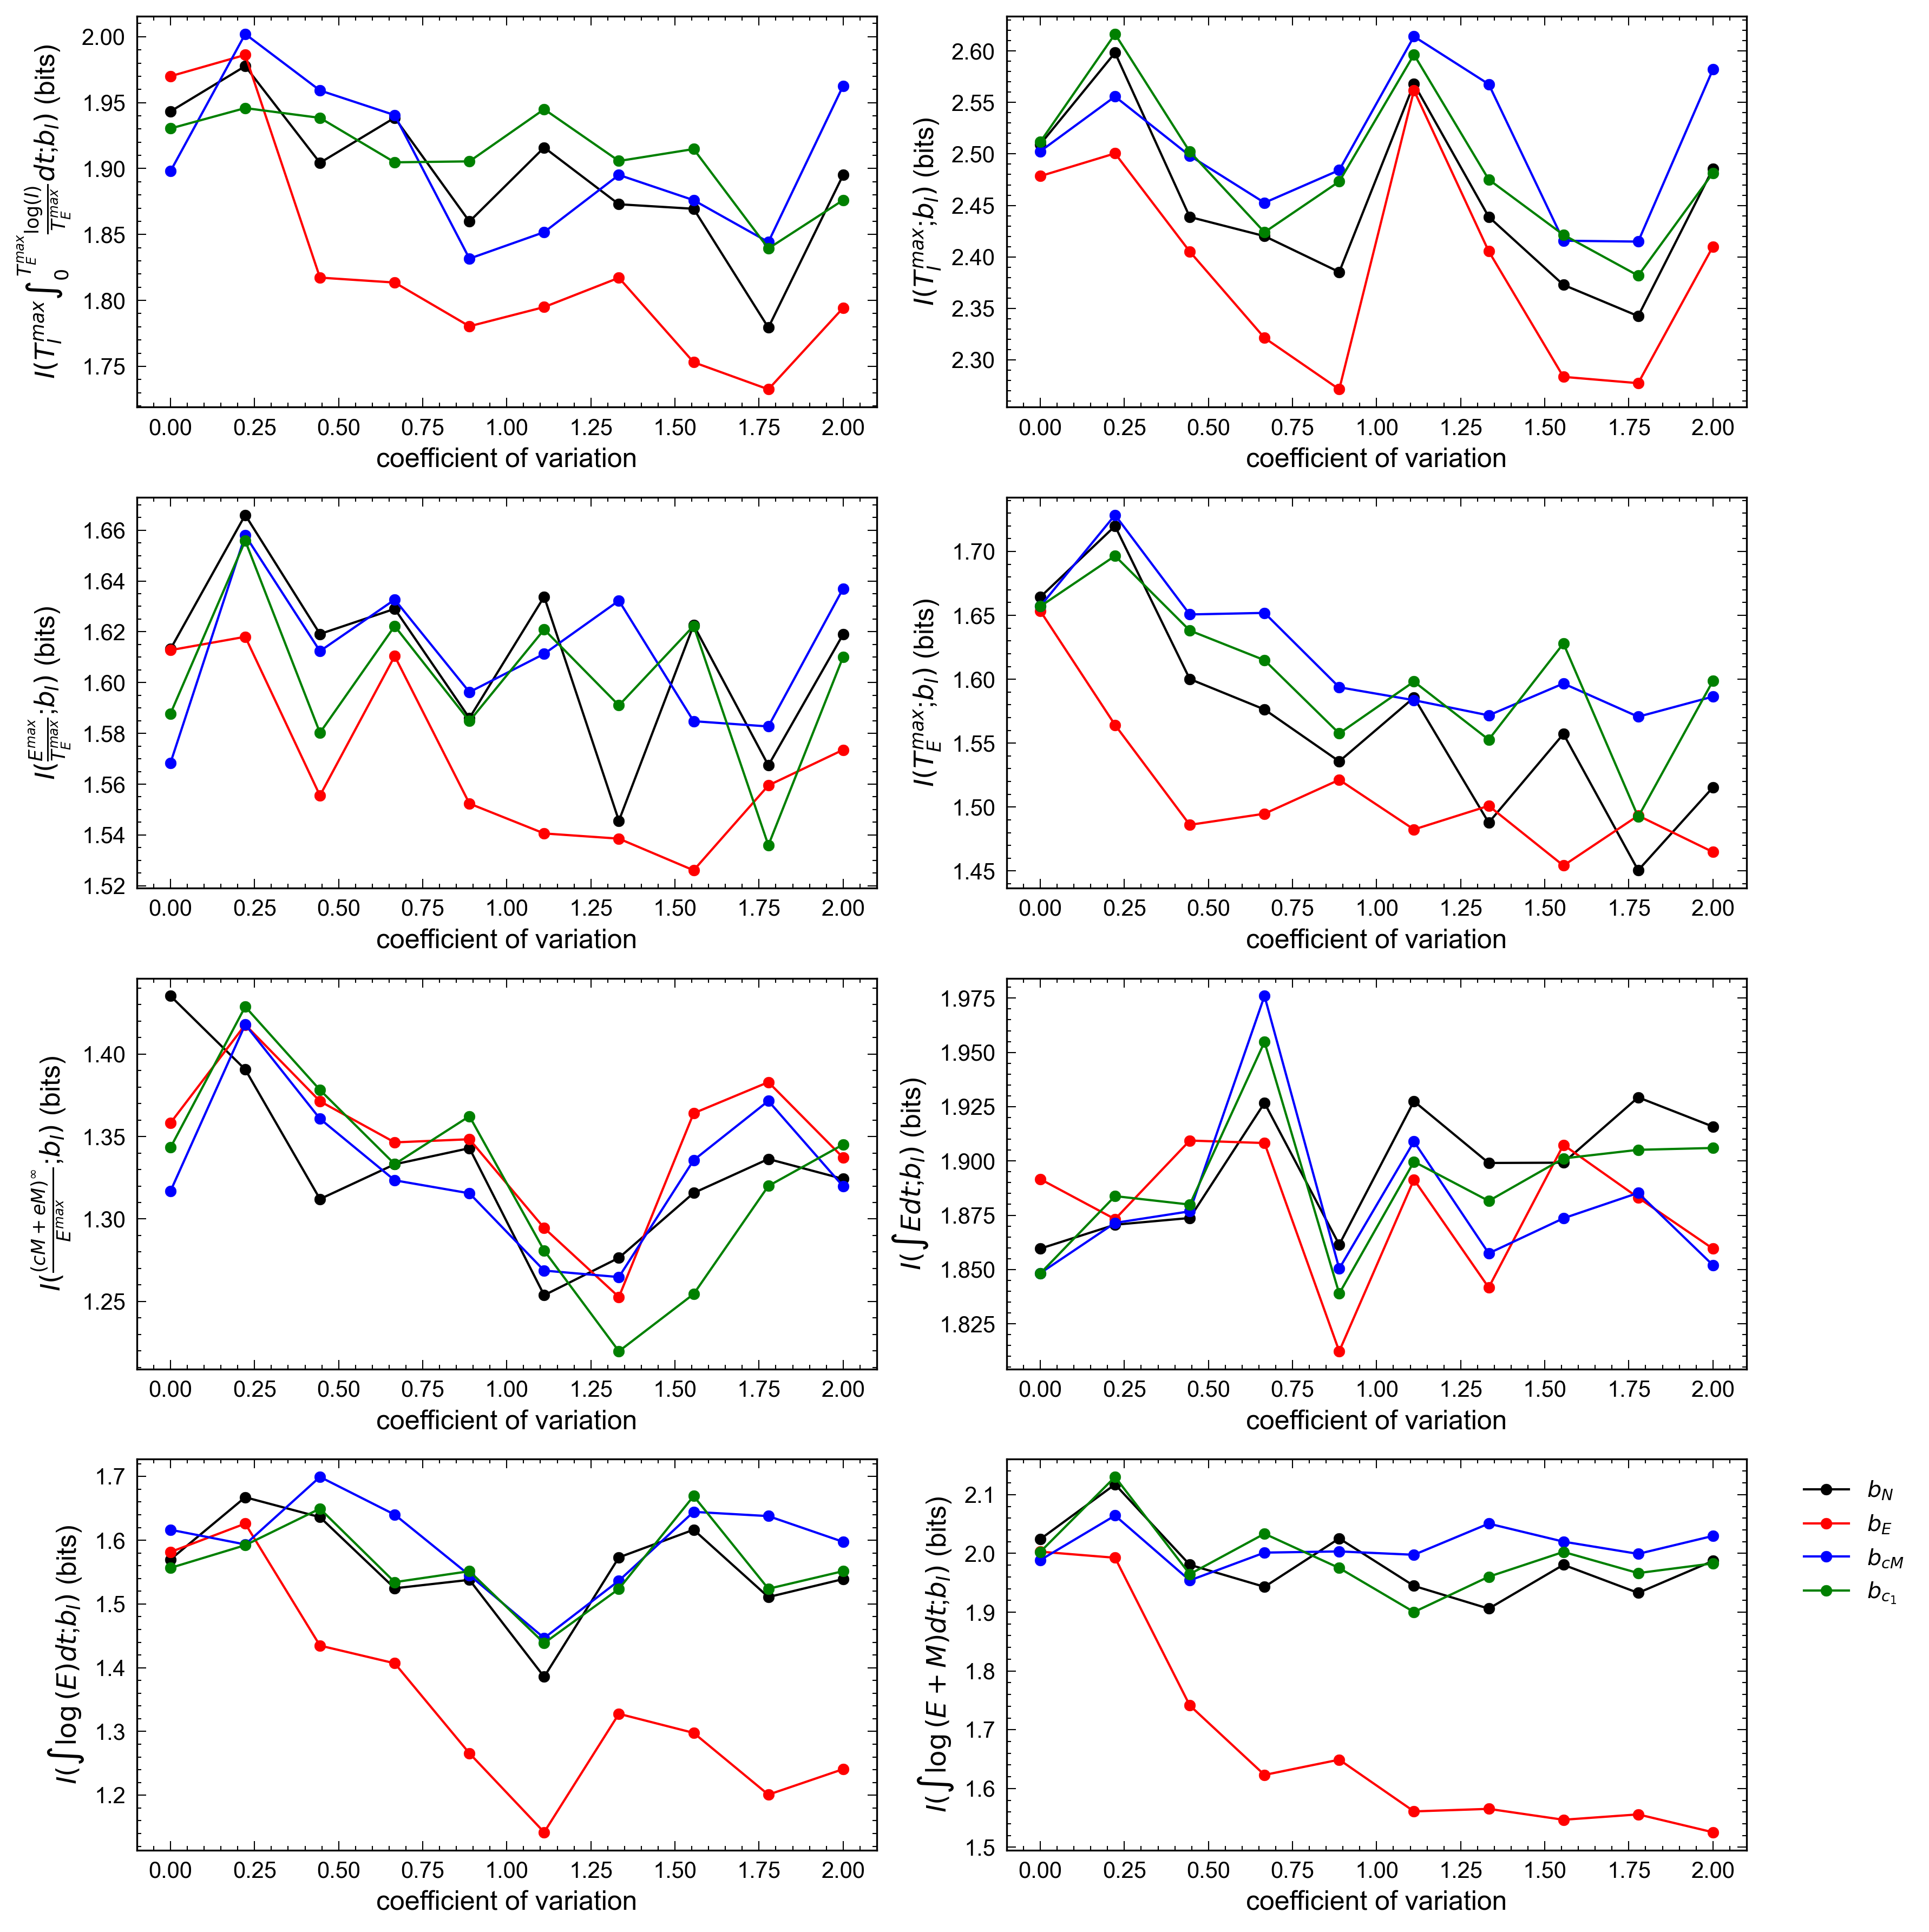

In [16]:
# plot surface maps
fig = plt.figure(figsize=(12,12),dpi = 150)

i = 0

for count, val in enumerate(stat_names[10:]):

    ax = fig.add_subplot(4, 2, i+1)
    ax.plot(cv_s, mi_data[:,count],'ko-', label = r'$b_N$')
    ax.plot(cv_s, mi_data[:,count+16],'ro-', label = r'$b_E$')
    ax.plot(cv_s, mi_data[:,count+32],'bo-', label = r'$b_{cM}$')
    ax.plot(cv_s, mi_data[:,count+48],'go-', label = r'$b_{c_1}$')
    
    

    #ax.set_title(val, fontsize = 12)
    # set the limits of the plot to the limits of the data
    #ax.axis([cv_g_ME.min(), cv_g_ME.max(), cv_g_ME.min(), cv_g_ME.max()])
    ax.set(xlabel='coefficient of variation', ylabel= r"$I($"+val+r";$b_I)$ (bits)")
    #fig.colorbar(cs,  shrink=0.5, aspect=8, label =r"I("+val+r";$t_1)$")

    i += 1

ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#fig.suptitle(r'$I(\cdot,b_I)$ as a function of variation in proliferation rates', fontsize = 16)
fig.savefig("_figs/"+sim_kind+'-'+infection_type+'-MI-vs-variation-virulence.pdf', dpi=150, bbox_inches="tight")
plt.tight_layout()

plt.show()

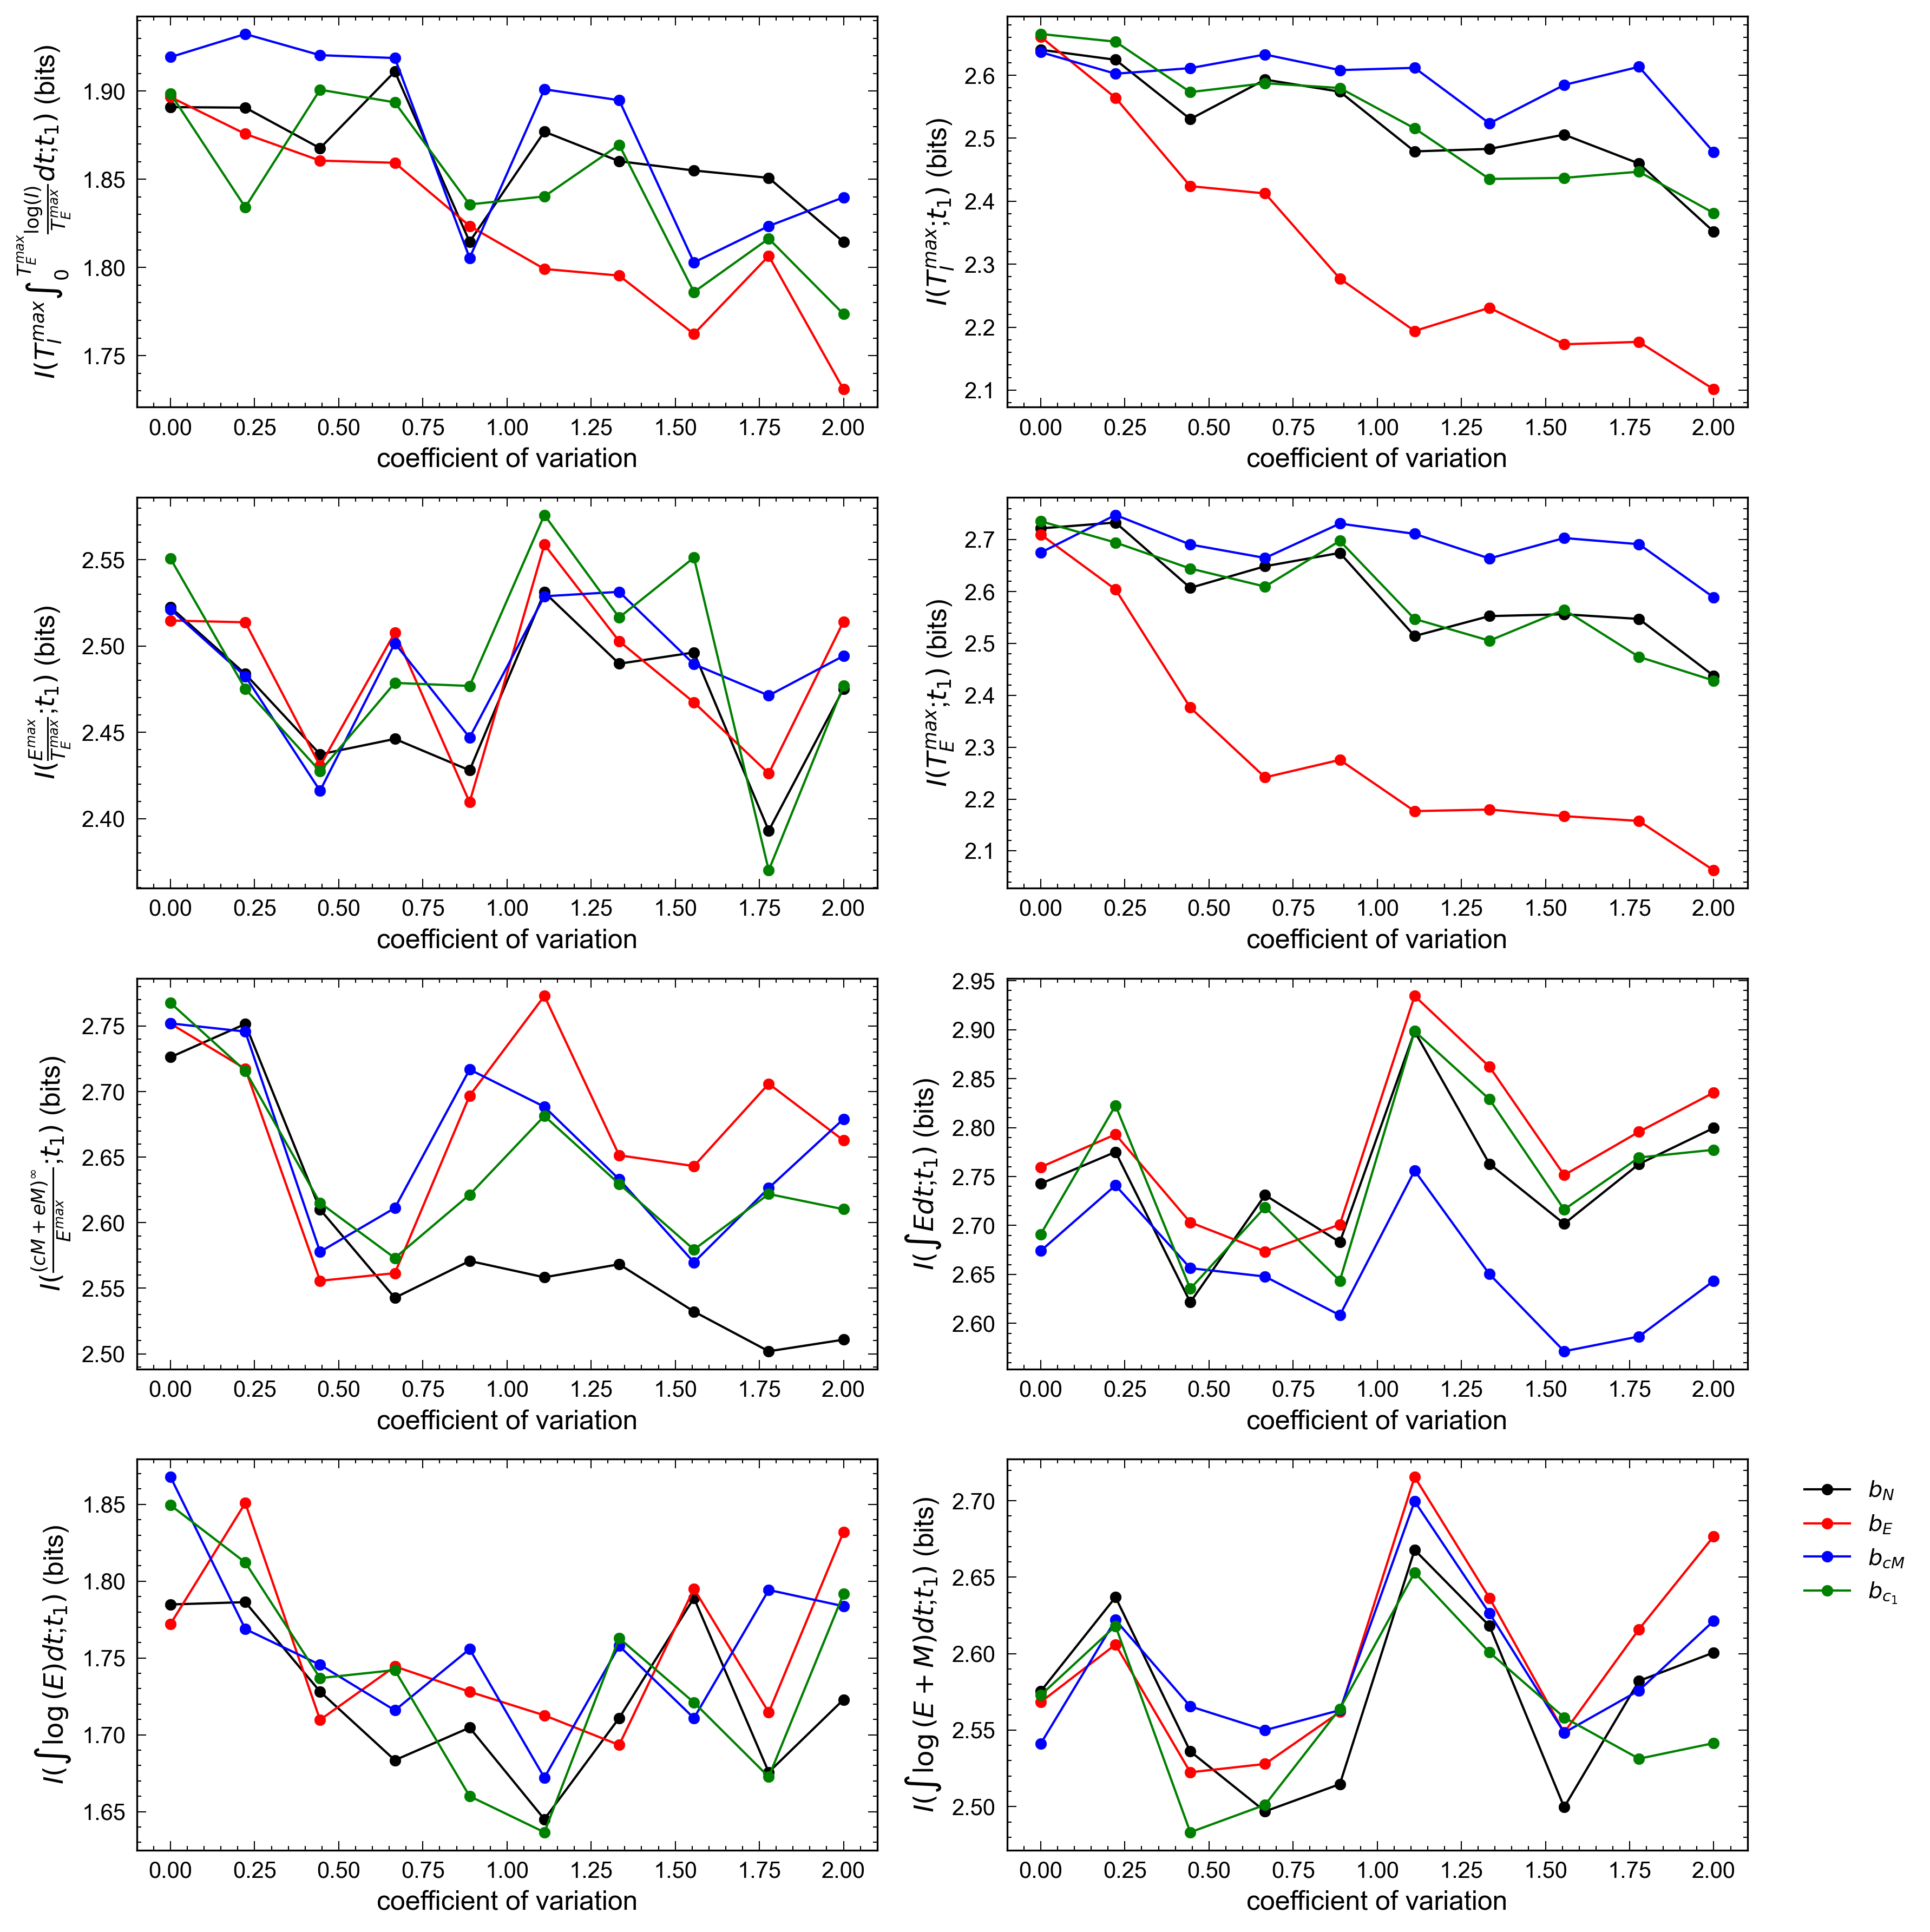

In [19]:
# plot surface maps
fig = plt.figure(figsize=(12,12),dpi = 150)

i = 0

for count, val in enumerate(stat_names[i+10:]):

    ax = fig.add_subplot(4, 2, i+1)
    ax.plot(cv_s, mi_data[:,count+8],'ko-', label = r'$b_N$')
    ax.plot(cv_s, mi_data[:,count+24],'ro-', label = r'$b_E$')
    ax.plot(cv_s, mi_data[:,count+40],'bo-', label = r'$b_{cM}$')
    ax.plot(cv_s, mi_data[:,count+56],'go-', label = r'$b_{c_1}$')
    
    

    #ax.set_title(val, fontsize = 12)
    # set the limits of the plot to the limits of the data
    ax.set(xlabel='coefficient of variation', ylabel= r"$I($"+val+r";$t_1)$ (bits)")
    #fig.colorbar(cs,  shrink=0.5, aspect=8, label =r"I("+val+r";$t_1)$")

    i += 1

ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#fig.suptitle(r'$I(\cdot,t_1)$ as a function of variation in proliferation rates', fontsize = 16)
fig.savefig("_figs/"+sim_kind+'-'+infection_type+'-MI-vs-variation-antigenicity.pdf', dpi=150, bbox_inches="tight")
plt.tight_layout()

plt.show()

In [6]:
# # plot heat maps
# fig_b_a1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout = True, figsize = (6,8))
# i = 4

# for ax, val in zip(axs.flat,stat_names[i:]):
#     z = extract_stats(MI_data_grid,i-3)
    
#     z = z[:-1, :-1]
#     z_min, z_max = np.abs(z).min(), np.abs(z).max()

#     cs = ax.pcolormesh(cv_b_E, cv_g_ME, z, cmap='RdBu', vmin=z_min, vmax=z_max)
    
#     ax.set_title(val)
#     # set the limits of the plot to the limits of the data
#     ax.axis([cv_b_E.min(), cv_b_E.max(), cv_g_ME.min(), cv_g_ME.max()])
#     ax.set(xlabel=r'CV of $b_E$', ylabel=r'CV of $g_{ME}$')
#     fig_b_a1.colorbar(cs, ax=ax)
        
#     i += 1
    
# fig_b_a1.suptitle(r'$I(\cdot,t_1)$ as a function of population noise')
# fig_b_a1.savefig('hmap-MI-vs_noise_t1.pdf', dpi=300, bbox_inches="tight")

